In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from tensorflow.keras.models import load_model

# Load binary best model directly (no JSON needed)
binary_model = load_model("/content/drive/MyDrive/Saved_Models/resnet_model.keras")
print("✅ Binary model loaded")

# Load multiclass best model
# Change filename to whichever multiclass model won (check your multiclass AUC table)
multi_model = load_model("/content/drive/MyDrive/multi_Saved_Models/resnet_model.keras")
print("✅ Multiclass model loaded")

Mounted at /content/drive
✅ Binary model loaded
✅ Multiclass model loaded


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

binary_preprocess = resnet_preprocess
multi_preprocess  = resnet_preprocess

BINARY_CLASSES = {0: "Normal", 1: "Osteoporosis"}
MULTI_CLASSES  = {0: "Normal", 1: "Osteopenia", 2: "Osteoporosis"}

print("✅ Setup complete")

✅ Setup complete


In [ ]:
# Run this to confirm class indices match your training
import os
import pandas as pd
from sklearn.model_selection import train_test_split

# Binary dataset
BINARY_DATASET = "/content/drive/MyDrive/Datasets/Unified_Osteoporosis"

filepaths, labels = [], []
for class_name in os.listdir(BINARY_DATASET):
    class_path = os.path.join(BINARY_DATASET, class_name)
    for file in os.listdir(class_path):
        filepaths.append(os.path.join(class_path, file))
        labels.append(class_name)

binary_df = pd.DataFrame({"filepath": filepaths, "label": labels})

train_df_b, temp_df_b = train_test_split(binary_df, test_size=0.30, stratify=binary_df["label"], random_state=42)
val_df_b, test_df_b   = train_test_split(temp_df_b, test_size=0.50, stratify=temp_df_b["label"], random_state=42)

temp_gen_b = tf.keras.preprocessing.image.ImageDataGenerator().flow_from_dataframe(
    test_df_b, x_col="filepath", y_col="label",
    target_size=(224,224), batch_size=32,
    class_mode="binary", shuffle=False
)
print("Binary class indices:", temp_gen_b.class_indices)
# Expected: {'normal': 0, 'osteoporosis': 1}

# Multiclass dataset
MULTI_DATASET = "/content/drive/MyDrive/Datasets/OS Collected Data"

filepaths2, labels2 = [], []
for class_name in os.listdir(MULTI_DATASET):
    class_path = os.path.join(MULTI_DATASET, class_name)
    for file in os.listdir(class_path):
        filepaths2.append(os.path.join(class_path, file))
        labels2.append(class_name)

multi_df = pd.DataFrame({"filepath": filepaths2, "label": labels2})

train_df_m, temp_df_m = train_test_split(multi_df, test_size=0.30, stratify=multi_df["label"], random_state=42)
val_df_m, test_df_m   = train_test_split(temp_df_m, test_size=0.50, stratify=temp_df_m["label"], random_state=42)

temp_gen_m = tf.keras.preprocessing.image.ImageDataGenerator().flow_from_dataframe(
    test_df_m, x_col="filepath", y_col="label",
    target_size=(224,224), batch_size=32,
    class_mode="categorical", shuffle=False
)
print("Multiclass class indices:", temp_gen_m.class_indices)
# Check exact order — update MULTI_CLASSES below if different

Found 460 validated image filenames belonging to 2 classes.
Binary class indices: {'normal': 0, 'osteoporosis': 1}
Found 293 validated image filenames belonging to 3 classes.
Multiclass class indices: {'Normal': 0, 'Osteopenia': 1, 'Osteoporosis': 2}


In [ ]:
# After running Cell 3, update these to match exactly what printed above

# Binary — usually {'normal': 0, 'osteoporosis': 1}
BINARY_CLASSES = {0: "Normal", 1: "Osteoporosis"}

# Multiclass — update based on what printed above
# Example: {'Normal': 0, 'Osteopenia': 1, 'Osteoporosis': 2}
MULTI_CLASSES = {0: "Normal", 1: "Osteopenia", 2: "Osteoporosis"}

print("Binary classes :", BINARY_CLASSES)
print("Multi classes  :", MULTI_CLASSES)

Binary classes : {0: 'Normal', 1: 'Osteoporosis'}
Multi classes  : {0: 'Normal', 1: 'Osteopenia', 2: 'Osteoporosis'}


In [ ]:
def generate_gradcam(model, img_array, last_conv_layer_name):
    """
    Works correctly with Sequential models wrapping ResNet50.
    Builds a new functional model using the base model's input/output directly.
    """
    # Get the base model (resnet50 layer inside Sequential)
    base_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            base_model = layer
            break

    if base_model is None:
        raise ValueError("No nested base model found")

    # Get the target conv layer from inside base model
    target_layer = base_model.get_layer(last_conv_layer_name)

    # Build a sub-model: base_model input → [conv output, base_model output]
    base_grad_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[target_layer.output, base_model.output]
    )

    # Get layers after base model (pooling, dense, dropout, etc.)
    post_layers = model.layers[1:]  # everything after base model

    with tf.GradientTape() as tape:
        # Forward through base model
        conv_out, base_out = base_grad_model(img_array)

        # Forward through remaining layers
        x = base_out
        for layer in post_layers:
            x = layer(x)

        preds = x

        if preds.shape[-1] == 1:
            loss = preds[:, 0]
        else:
            pred_index = tf.argmax(preds[0])
            loss = preds[:, pred_index]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def get_last_conv_layer_name(model):
    """
    Finds last Conv2D layer name inside the nested base model.
    Returns just the layer name string.
    """
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            for sublayer in reversed(layer.layers):
                if isinstance(sublayer, tf.keras.layers.Conv2D):
                    print(f"✅ Found in '{layer.name}': {sublayer.name}")
                    return sublayer.name
    raise ValueError("No Conv2D layer found")


import cv2

def overlay_heatmap(original_img_array, heatmap, alpha=0.4):
    """
    Resizes heatmap to match image size before overlaying.
    Fixes (7,7) heatmap vs (224,224) image mismatch.
    """
    img = np.uint8(original_img_array)

    # Resize heatmap to match image dimensions (224x224)
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Normalize to 0-255
    heatmap_uint8 = np.uint8(255 * heatmap_resized)

    # Apply jet colormap
    heatmap_colored = np.uint8(255 * cm.jet(heatmap_uint8)[:, :, :3])

    # Blend
    superimposed = np.clip(heatmap_colored * alpha + img, 0, 255).astype("uint8")

    return img, superimposed


# Get conv layer names
binary_conv_layer = get_last_conv_layer_name(binary_model)
multi_conv_layer  = get_last_conv_layer_name(multi_model)

print("\nBinary conv layer :", binary_conv_layer)
print("Multi  conv layer :", multi_conv_layer)

✅ Found in 'resnet50': conv5_block3_3_conv
✅ Found in 'resnet50': conv5_block3_3_conv

Binary conv layer : conv5_block3_3_conv
Multi  conv layer : conv5_block3_3_conv


In [ ]:
def get_risk_level(binary_prob, multi_probs=None):
    """
    Returns risk_percentage and risk_label.
    If Normal from binary → use binary prob directly.
    If Osteoporosis from binary → use multiclass severity.
    """
    if multi_probs is None:
        # Normal case — binary only
        risk_pct = (1 - binary_prob) * 100  # confidence of being normal
        risk_pct = binary_prob * 100         # risk of osteoporosis
        if risk_pct < 30:
            return risk_pct, "🟢 Low Risk"
        elif risk_pct < 60:
            return risk_pct, "🟡 Moderate Risk"
        else:
            return risk_pct, "🔴 High Risk"
    else:
        severity_idx = np.argmax(multi_probs)
        severity_label = MULTI_CLASSES[severity_idx]
        risk_pct = float(multi_probs[severity_idx]) * 100

        if severity_label == "Normal":
            return risk_pct, "🟢 Low Risk"
        elif severity_label == "Osteopenia":
            return risk_pct, "🟡 Moderate Risk"
        else:
            return risk_pct, "🔴 High Risk"

In [ ]:
def run_pipeline(img_path):
    print("=" * 50)
    print("🩻 OSTEOPOROSIS RISK STRATIFICATION PIPELINE")
    print("=" * 50)

    # Load original image
    img = keras_image.load_img(img_path, target_size=(224, 224))
    img_orig = keras_image.img_to_array(img)

    # ─── STAGE 1: BINARY ─────────────────────────────
    img_binary = binary_preprocess(np.expand_dims(img_orig.copy(), axis=0))

    binary_prob = float(binary_model.predict(img_binary, verbose=0)[0][0])
    binary_label = "Osteoporosis" if binary_prob > 0.5 else "Normal"
    binary_confidence = binary_prob if binary_label == "Osteoporosis" else 1 - binary_prob

    # Grad-CAM binary
    try:
        binary_heatmap = generate_gradcam(binary_model, img_binary, binary_conv_layer)
        _, binary_overlay = overlay_heatmap(img_orig.copy(), binary_heatmap)
        show_gradcam = True
    except Exception as e:
        print(f"⚠️ Grad-CAM failed: {e}")
        show_gradcam = False

    print(f"\n🔵 STAGE 1 — Binary Screening")
    print(f"   Result     : {binary_label}")
    print(f"   Confidence : {binary_confidence:.1%}")

    # ─── NORMAL PATH ─────────────────────────────────
    if binary_label == "Normal":
        risk_pct, risk_label = get_risk_level(binary_prob)
        print(f"   Risk Score : {risk_pct:.1f}%")
        print(f"   Risk Level : {risk_label}")
        print(f"\n✅ No osteoporosis detected. No further staging needed.")

        if show_gradcam:
            fig, axes = plt.subplots(1, 3, figsize=(14, 4))
            axes[0].imshow(img_orig.astype("uint8"))
            axes[0].set_title("Original X-Ray"); axes[0].axis("off")
            axes[1].imshow(binary_heatmap, cmap="jet")
            axes[1].set_title("Grad-CAM Heatmap"); axes[1].axis("off")
            axes[2].imshow(binary_overlay)
            axes[2].set_title(f"Overlay\n{binary_label} ({binary_confidence:.1%})"); axes[2].axis("off")
            plt.suptitle(f"Stage 1 — Binary | {risk_label}", fontsize=13, fontweight="bold")
            plt.tight_layout(); plt.show()

        return {
            "stage": 1,
            "binary_label": binary_label,
            "binary_confidence": round(binary_confidence, 4),
            "risk_score": round(risk_pct, 2),
            "risk_level": risk_label,
            "severity": None
        }

    # ─── STAGE 2: MULTICLASS ─────────────────────────
    print(f"\n🔴 Osteoporosis detected — running severity staging...")

    img_multi = multi_preprocess(np.expand_dims(img_orig.copy(), axis=0))
    multi_probs = multi_model.predict(img_multi, verbose=0)[0]
    severity_idx = int(np.argmax(multi_probs))
    severity_label = MULTI_CLASSES[severity_idx]
    severity_confidence = float(multi_probs[severity_idx])

    risk_pct, risk_label = get_risk_level(binary_prob, multi_probs)

    # Grad-CAM multiclass
    try:
        multi_heatmap = generate_gradcam(multi_model, img_multi, multi_conv_layer)
        _, multi_overlay = overlay_heatmap(img_orig.copy(), multi_heatmap)
        show_multi_gradcam = True
    except Exception as e:
        print(f"⚠️ Multiclass Grad-CAM failed: {e}")
        show_multi_gradcam = False

    print(f"\n🟠 STAGE 2 — Severity Classification")
    print(f"   Severity   : {severity_label}")
    print(f"   Confidence : {severity_confidence:.1%}")
    print(f"   Risk Score : {risk_pct:.1f}%")
    print(f"   Risk Level : {risk_label}")
    print(f"\n   Class Probabilities:")
    for idx, prob in enumerate(multi_probs):
        print(f"      {MULTI_CLASSES[idx]:<15}: {prob:.1%}")

    if show_gradcam and show_multi_gradcam:
        fig, axes = plt.subplots(2, 3, figsize=(14, 9))

        axes[0][0].imshow(img_orig.astype("uint8"))
        axes[0][0].set_title("Original X-Ray"); axes[0][0].axis("off")
        axes[0][1].imshow(binary_heatmap, cmap="jet")
        axes[0][1].set_title("Stage 1 — Heatmap"); axes[0][1].axis("off")
        axes[0][2].imshow(binary_overlay)
        axes[0][2].set_title(f"Stage 1: {binary_label} ({binary_confidence:.1%})"); axes[0][2].axis("off")

        axes[1][0].imshow(img_orig.astype("uint8"))
        axes[1][0].set_title("Original X-Ray"); axes[1][0].axis("off")
        axes[1][1].imshow(multi_heatmap, cmap="jet")
        axes[1][1].set_title("Stage 2 — Heatmap"); axes[1][1].axis("off")
        axes[1][2].imshow(multi_overlay)
        axes[1][2].set_title(f"Stage 2: {severity_label} ({severity_confidence:.1%})"); axes[1][2].axis("off")

        plt.suptitle(f"Two-Stage Pipeline | {severity_label} | {risk_label}",
                     fontsize=13, fontweight="bold")
        plt.tight_layout(); plt.show()

    return {
        "stage": 2,
        "binary_label": binary_label,
        "binary_confidence": round(binary_confidence, 4),
        "severity": severity_label,
        "severity_confidence": round(severity_confidence, 4),
        "risk_score": round(risk_pct, 2),
        "risk_level": risk_label
    }

🩻 OSTEOPOROSIS RISK STRATIFICATION PIPELINE

🔵 STAGE 1 — Binary Screening
   Result     : Normal
   Confidence : 99.6%
   Risk Score : 0.4%
   Risk Level : 🟢 Low Risk

✅ No osteoporosis detected. No further staging needed.


/tmp/ipykernel_2646/390850540.py:46: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


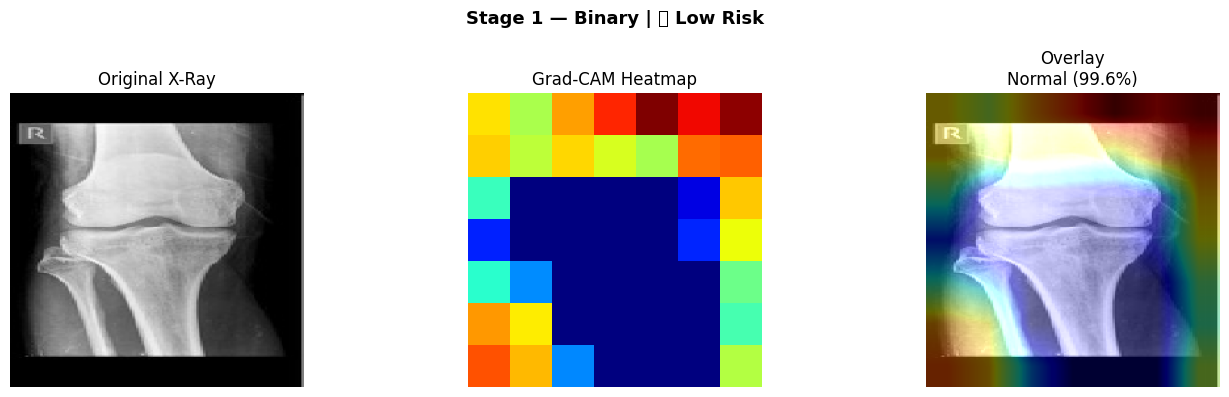


📦 Returned Result Dict: {'stage': 1, 'binary_label': 'Normal', 'binary_confidence': 0.9958, 'risk_score': 0.42, 'risk_level': '🟢 Low Risk', 'severity': None}


In [ ]:
# Test with a Normal image
normal_sample = test_df_b[test_df_b["label"] == "normal"].iloc[0]["filepath"]
result = run_pipeline(normal_sample)

print("\n📦 Returned Result Dict:", result)

🩻 OSTEOPOROSIS RISK STRATIFICATION PIPELINE

🔵 STAGE 1 — Binary Screening
   Result     : Osteoporosis
   Confidence : 100.0%

🔴 Osteoporosis detected — running severity staging...

🟠 STAGE 2 — Severity Classification
   Severity   : Osteoporosis
   Confidence : 99.9%
   Risk Score : 99.9%
   Risk Level : 🔴 High Risk

   Class Probabilities:
      Normal         : 0.0%
      Osteopenia     : 0.0%
      Osteoporosis   : 99.9%


/tmp/ipykernel_2646/390850540.py:105: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout(); plt.show()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


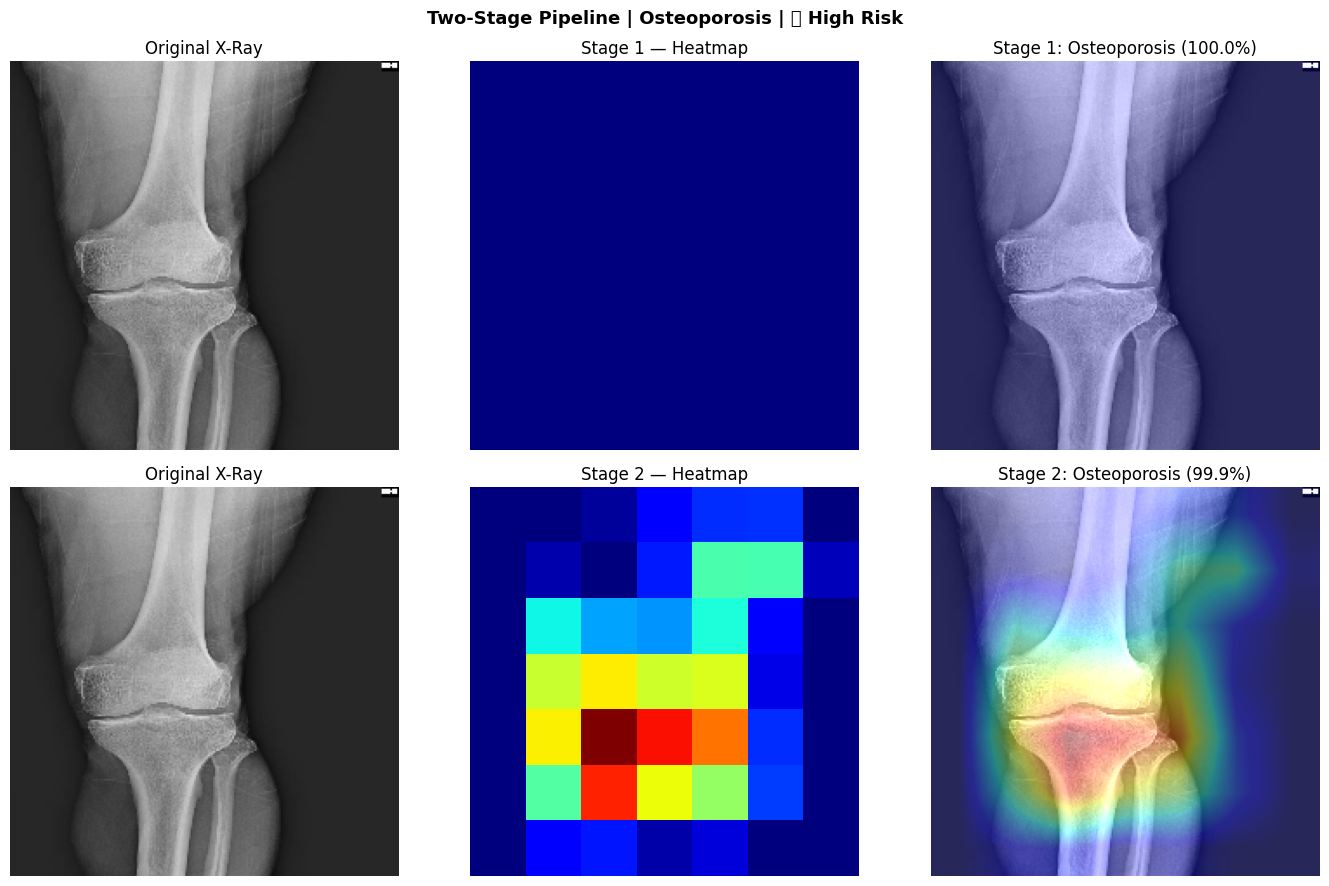


📦 Returned Result Dict: {'stage': 2, 'binary_label': 'Osteoporosis', 'binary_confidence': 1.0, 'severity': 'Osteoporosis', 'severity_confidence': 0.9994, 'risk_score': 99.94, 'risk_level': '🔴 High Risk'}


In [ ]:
# Test with an Osteoporosis image
osteo_sample = test_df_b[test_df_b["label"] == "osteoporosis"].iloc[0]["filepath"]
result = run_pipeline(osteo_sample)

print("\n📦 Returned Result Dict:", result)

In [ ]:
!pip install gradio -q

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import cv2
from PIL import Image
from tensorflow.keras.preprocessing import image as keras_image
from tensorflow.keras.applications.resnet50 import preprocess_input as resnet_preprocess

# ─── Helper: Grad-CAM ────────────────────────────────────────────
def generate_gradcam_gradio(model, img_array, last_conv_layer_name):
    base_model = None
    for layer in model.layers:
        if isinstance(layer, tf.keras.Model):
            base_model = layer
            break

    target_layer = base_model.get_layer(last_conv_layer_name)

    base_grad_model = tf.keras.Model(
        inputs=base_model.input,
        outputs=[target_layer.output, base_model.output]
    )

    post_layers = model.layers[1:]

    with tf.GradientTape() as tape:
        conv_out, base_out = base_grad_model(img_array)
        x = base_out
        for layer in post_layers:
            x = layer(x)
        preds = x
        if preds.shape[-1] == 1:
            loss = preds[:, 0]
        else:
            pred_index = tf.argmax(preds[0])
            loss = preds[:, pred_index]

    grads = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_out[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_heatmap_gradio(original_img_array, heatmap, alpha=0.4):
    img = np.uint8(original_img_array)
    heatmap_resized = cv2.resize(heatmap, (img.shape[1], img.shape[0]))
    heatmap_uint8 = np.uint8(255 * heatmap_resized)
    heatmap_colored = np.uint8(255 * cm.jet(heatmap_uint8)[:, :, :3])
    superimposed = np.clip(heatmap_colored * alpha + img, 0, 255).astype("uint8")
    return superimposed


# ─── Main Prediction Function ─────────────────────────────────────
def predict_osteoporosis(input_image):
    # Convert PIL to numpy
    img = input_image.resize((224, 224))
    img_orig = np.array(img).astype("float32")

    # ── STAGE 1: BINARY ──────────────────────────────────────────
    img_binary = resnet_preprocess(np.expand_dims(img_orig.copy(), axis=0))
    binary_prob = float(binary_model.predict(img_binary, verbose=0)[0][0])
    binary_label = "Osteoporosis" if binary_prob > 0.5 else "Normal"
    binary_confidence = binary_prob if binary_label == "Osteoporosis" else 1 - binary_prob

    # Grad-CAM binary
    try:
        binary_heatmap = generate_gradcam_gradio(binary_model, img_binary, binary_conv_layer)
        binary_overlay = overlay_heatmap_gradio(img_orig.copy(), binary_heatmap)
        binary_gradcam_img = Image.fromarray(binary_overlay)
    except Exception as e:
        binary_gradcam_img = Image.fromarray(np.uint8(img_orig))

    # ── NORMAL PATH ──────────────────────────────────────────────
    if binary_label == "Normal":
        risk_pct = binary_prob * 100
        if risk_pct < 30:
            risk_label = "Low Risk"
            risk_color = "#2ecc71"
        elif risk_pct < 60:
            risk_label = "Moderate Risk"
            risk_color = "#f39c12"
        else:
            risk_label = "High Risk"
            risk_color = "#e74c3c"

        report = f"""
## Result: Normal

**Stage 1 — Binary Screening**
- Prediction   : {binary_label}
- Confidence   : {binary_confidence:.1%}
- Risk Score   : {risk_pct:.1f}%
- Risk Level   : {risk_label}

---
No further staging required.
        """
        return (
            binary_gradcam_img,
            Image.fromarray(np.uint8(img_orig)),
            report
        )

    # ── STAGE 2: MULTICLASS ──────────────────────────────────────
    img_multi = resnet_preprocess(np.expand_dims(img_orig.copy(), axis=0))
    multi_probs = multi_model.predict(img_multi, verbose=0)[0]
    severity_idx = int(np.argmax(multi_probs))
    severity_label = MULTI_CLASSES[severity_idx]
    severity_confidence = float(multi_probs[severity_idx])

    risk_pct = severity_confidence * 100
    if severity_label == "Normal":
        risk_label = "Low Risk"
    elif severity_label == "Osteopenia":
        risk_label = "Moderate Risk"
    else:
        risk_label = "High Risk"

    # Grad-CAM multiclass
    try:
        multi_heatmap = generate_gradcam_gradio(multi_model, img_multi, multi_conv_layer)
        multi_overlay = overlay_heatmap_gradio(img_orig.copy(), multi_heatmap)
        multi_gradcam_img = Image.fromarray(multi_overlay)
    except Exception as e:
        multi_gradcam_img = Image.fromarray(np.uint8(img_orig))

    report = f"""
## Result: Osteoporosis Detected

**Stage 1 — Binary Screening**
- Prediction   : {binary_label}
- Confidence   : {binary_confidence:.1%}

---

**Stage 2 — Severity Classification**
- Severity     : {severity_label}
- Confidence   : {severity_confidence:.1%}
- Risk Score   : {risk_pct:.1f}%
- Risk Level   : {risk_label}

---

**Class Probabilities**
- Normal       : {multi_probs[0]:.1%}
- Osteopenia   : {multi_probs[1]:.1%}
- Osteoporosis : {multi_probs[2]:.1%}

---
*This tool is for research purposes only. Consult a medical professional for diagnosis.*
    """

    return (
        binary_gradcam_img,
        multi_gradcam_img,
        report
    )


# ─── Gradio Interface ─────────────────────────────────────────────
with gr.Blocks(title="Osteoporosis Risk Stratification", theme=gr.themes.Soft()) as demo:

    gr.Markdown("""
    # 🦴 Osteoporosis Risk Stratification System
    ### Two-Stage AI Pipeline: Binary Screening → Severity Classification
    Upload a knee X-ray image to get a risk assessment.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            input_img = gr.Image(
                type="pil",
                label="Upload X-Ray Image"
            )
            submit_btn = gr.Button("Analyze", variant="primary", size="lg")

        with gr.Column(scale=2):
            with gr.Row():
                stage1_img = gr.Image(label="Stage 1 — Binary Grad-CAM")
                stage2_img = gr.Image(label="Stage 2 — Severity Grad-CAM")

            report_output = gr.Markdown(label="Analysis Report")

    gr.Markdown("""
    ---
    **How it works:**
    - **Stage 1** screens for presence of osteoporosis (Normal vs Osteoporosis)
    - **Stage 2** classifies severity if osteoporosis is detected (Normal / Osteopenia / Osteoporosis)
    - **Grad-CAM** highlights the bone regions the model focused on
    """)

    submit_btn.click(
        fn=predict_osteoporosis,
        inputs=input_img,
        outputs=[stage1_img, stage2_img, report_output]
    )

demo.launch(share=True, debug=True)

/tmp/ipykernel_2646/520537915.py:165: DeprecationWarning: The 'theme' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'theme' to Blocks.launch() instead.
  with gr.Blocks(title="Osteoporosis Risk Stratification", theme=gr.themes.Soft()) as demo:


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://4781cb71eb7cd5ab75.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
